## Customer Churn Analysis

Import all the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import the csv file now

In [2]:
df = pd.read_csv("C:\\Users\\Dhruv03\\OneDrive\\Desktop\\Data Analytics Projects\\Customer Churn\\Customer churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


check the head and tail of data to see all values from excel are there.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


check for the info about its columns and its datatype and check if datatype matches the data we were expecting

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

We found that data we had an object datatype for total charges column which was only supposed to have float data so we found blank spaces where totalcharges are 0 and then we replace blank spaced by zero and changed its type to float. we replaced blanks with 0 as tenure is 0 and no total charges are recorded.

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

we check info again and now total charges are float again.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

check if there are any null values in data and then put 1st sum to see sum on null in evey column and second one gives us total no. of columns with null.

In [7]:
df.isnull().sum().sum()

np.int64(0)

check for description of data where we can see all needed details about the columns with int or float values

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


checked to see if any data was duplicated.

In [9]:
df.duplicated().sum()

np.int64(0)

always recheck data with the unique value column in the data to check for any repeated value

In [10]:
df["customerID"].duplicated().sum()

np.int64(0)

we also saw in desciption that senior citizen is returning data in int when it is more clear in yes and no format so we made a python function to put those values in place of 0 and 1 and then apply it.

In [11]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"]= df["SeniorCitizen"].apply(conv)

use head of data to see if changes made have been implemented correctly on  data or not.

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


we want to see data about count of churn in table thats why we used sns churn plot where we put churn data on x axis and give data from df. we also used bar_label and containers to show the count sum in the top of bars in the graph.

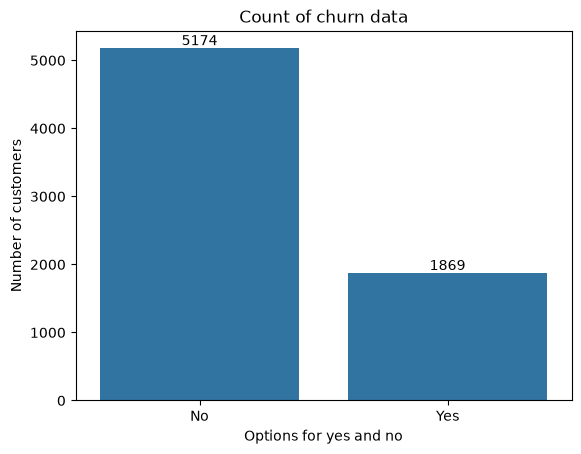

In [13]:
ax = sns.countplot(x='Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of churn data")
plt.xlabel("Options for yes and no")
plt.ylabel("Number of customers")
plt.show()

if we need percentage of count we use pie chart and as data is in float so we have to use groupby and aggregate the count of data first anf then use autopct to show data in pie chart form with data in percentage.

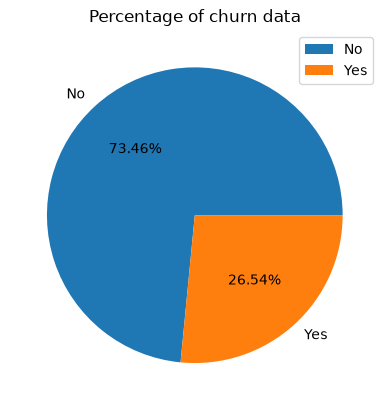

In [14]:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of churn data")
plt.legend()
plt.show()

we can see from pie chart that 26.54% of out customers have churned out. now we need to find the reason for it

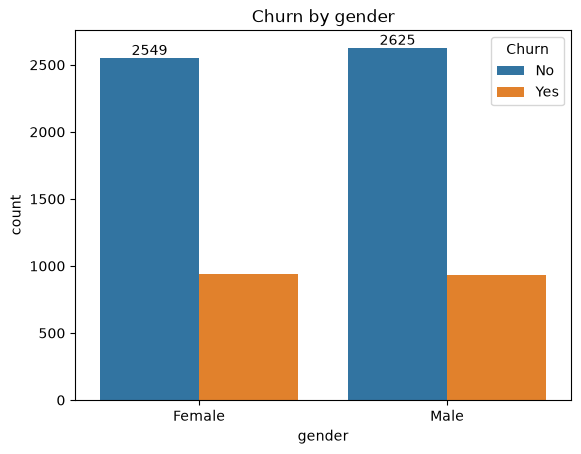

In [15]:
ab = sns.countplot(x=df["gender"], data=df,hue="Churn")
ab.bar_label(ab.containers[0])
plt.title("Churn by gender")
plt.show()

from this we can see that it is not due to any gender issue.

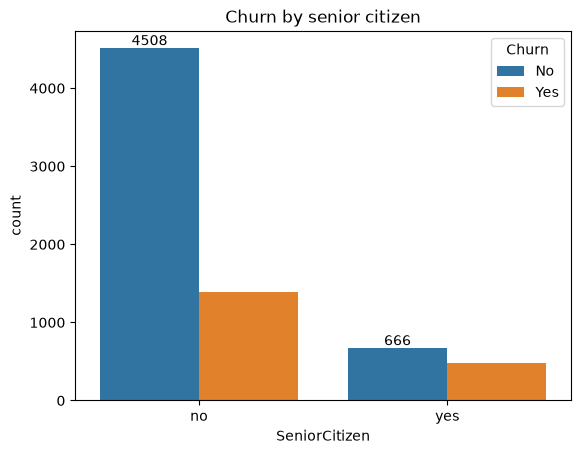

In [16]:
ab = sns.countplot(x=df["SeniorCitizen"], data=df,hue="Churn")
ab.bar_label(ab.containers[0])
plt.title("Churn by senior citizen")
plt.show()

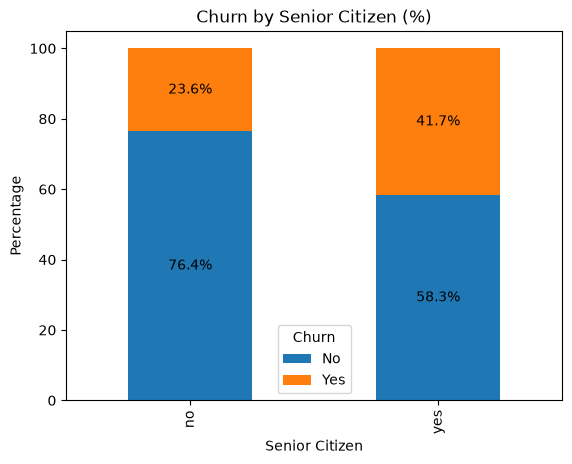

In [17]:
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])

# Convert to % of total
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax = ct_percent.plot(kind="bar", stacked=True)

# Add % labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.title("Churn by Senior Citizen (%)")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

comparetively more people in senior citize category have churned out.

now we can analyze data on basis of the tenure as well where the max tenure we provide is 72 months.

plt.figure(figsize =(9,4))
sns.histplot(x="tenure", data = df,bins = 72,hue=("Churn"))

plt.show()

from this data we can see that most people churned out in 1st month of tenure with a minute noticeable number in 2nd month after which the churn out isnt visible in the graph.

now we analyze the data on the basis of contract

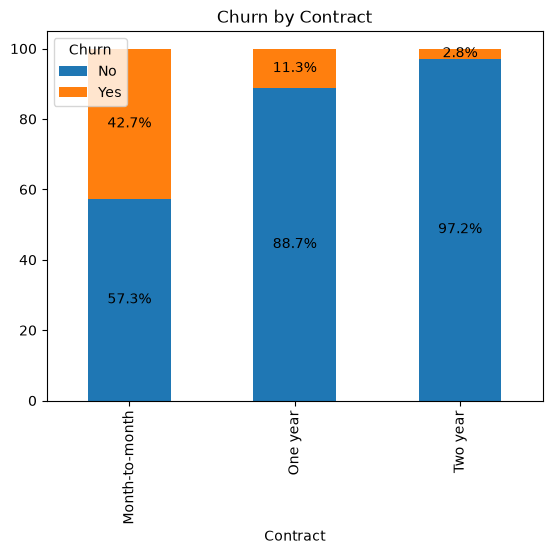

In [18]:
ct = pd.crosstab(df["Contract"], df["Churn"])
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100
ax = ct_percent.plot(kind="bar", stacked=True)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.title("Churn by Contract")
plt.legend(title="Churn")
plt.show()

from this we can deduce that ones with month-to-month contract have been churned out comparetively more than the yearly or bi-yearly contract.

In [19]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

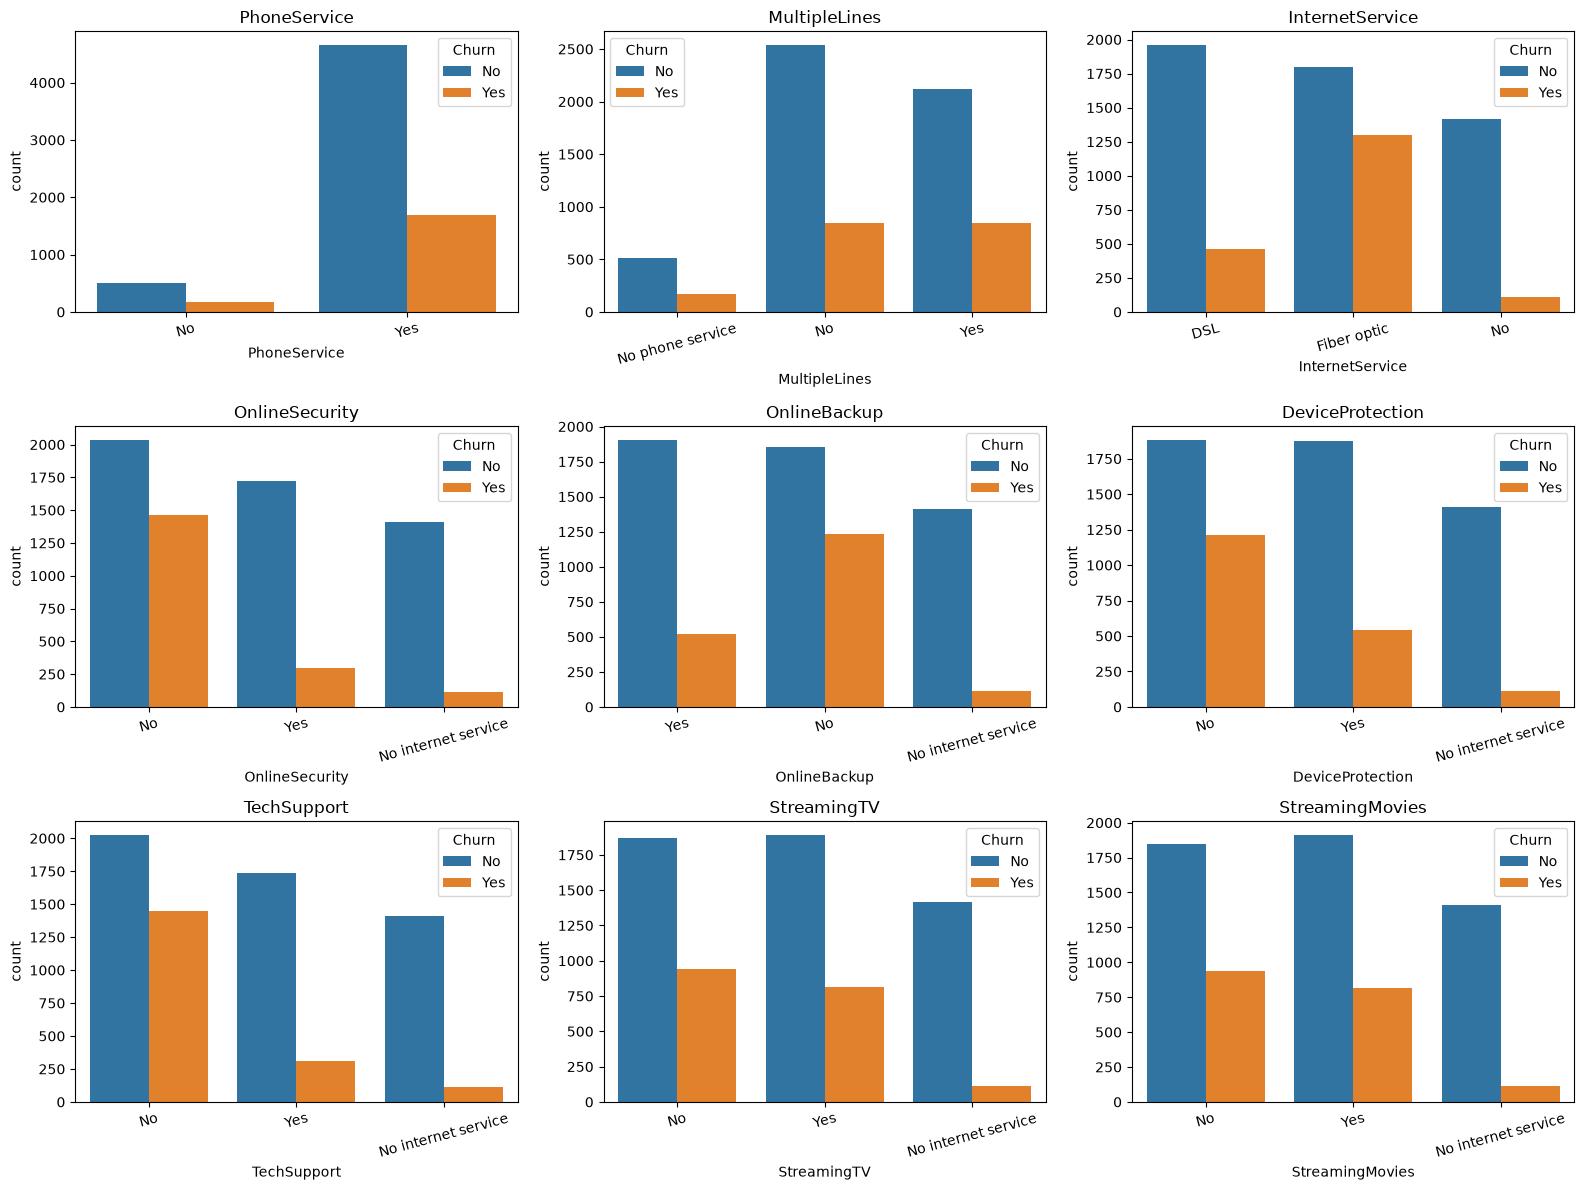

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid (3 rows × 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue="Churn")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


Observation for all these graphs are following:
1. in phoneservice, people who have it are churing out but its not a significant amount.
2. in multiplelines, it is observed that people with no multiple lines and people who do have them are churning out the same so its not a factor.
3. in internetservice, it is observed that customers with fiber optic internet service are churning out in a significant amount which needs to be addressed.
4. in onlinesecurity, it is observed that customers under no category are churning out significantly.
5. in onlinebackup, it is observed that people under no category are churnning out significantly which neeeds to be addressed.
6. in deviceprotection, it is observed that people under no category are churnning out significantly which neeeds to be addressed.
7. in techsupport, it is observed that people under no category are churning out significantly which neeeds to be addressed.
8. in streamingtv, it is observed that people under no and people under yes are churning out the same so its not a factor.
9. in streamingmovies, it is observed that people under no and people under yes are churning out the same so its not a factor.

now we need to analyze the payment method data for further exploration

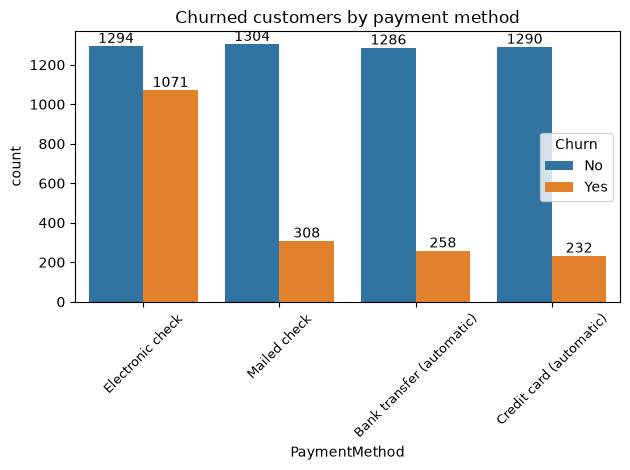

In [21]:
am = sns.countplot(x="PaymentMethod", data=df, hue="Churn")
am.set_title("Churned customers by payment method")
am.bar_label(am.containers[0])
am.bar_label(am.containers[1])
am.tick_params(axis='x', labelsize=9, rotation=45)
plt.tight_layout()
plt.show()

Analyzing and observing this bars has shown the infromation that people whose payment methods are set to electronic cheque are churning out the most 